## Simple Linear Regression

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [24]:
## Read the dataset
df = pd.read_csv("height-weight.csv")
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


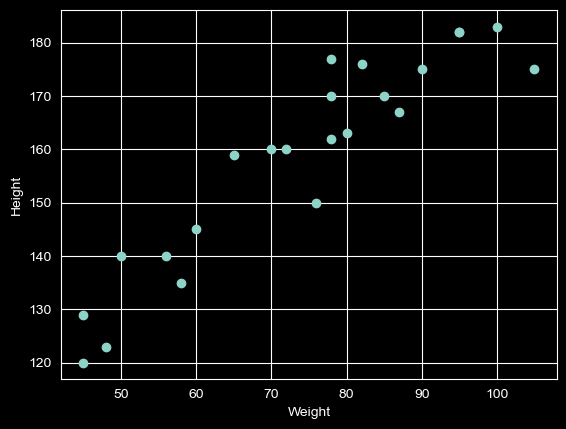

In [25]:
plt.scatter(df['Weight'],df['Height'])
plt.xlabel('Weight')
plt.ylabel('Height')
plt.show()

### Divide our dataset into Independent and dependent features

In [26]:
X = df[['Weight']] # Independent feature
y = df['Height'] # Dependent feature

In [27]:
y

0     120
1     135
2     123
3     145
4     160
5     162
6     163
7     175
8     182
9     170
10    176
11    182
12    175
13    183
14    170
15    177
16    140
17    159
18    150
19    167
20    129
21    140
22    160
Name: Height, dtype: int64

### Train Test Split of Dataset

In [28]:
from sklearn.model_selection import train_test_split

In [29]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20, random_state=42)

In [30]:
X.shape ## Before train test split

(23, 1)

In [31]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((18, 1), (5, 1), (18,), (5,))

### Standardize the data

In standardized data:-
* Mean = 0
* Standard Deviation = 1
* Helps when features have different scales
* Imporves model stability, gradient descent convergence, and coefficient interpretetion.

In [32]:
## Standardize the data (Train independent features)
from sklearn.preprocessing import StandardScaler

In [33]:
scaler = StandardScaler()

In [34]:
X_train

,Weight
12,105
1,58
13,100
5,78
2,48
11,95
20,45
3,60
4,70
18,76


In [35]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

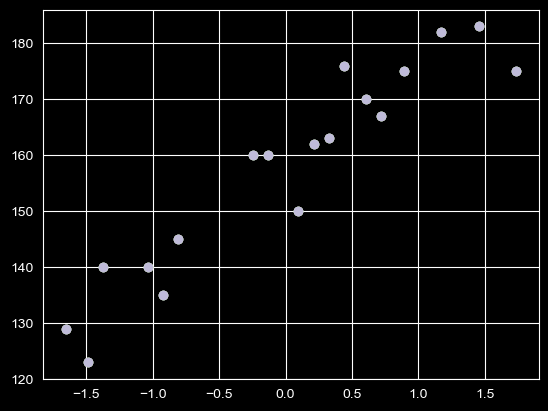

In [38]:
plt.scatter(X_train,y_train)
plt.show()

### Train the model --> Simple Linear Regression

In [40]:
from sklearn.linear_model import LinearRegression

In [41]:
model = LinearRegression()

In [42]:
model.fit(X_train,y_train)

LinearRegression()

In [47]:
print("Slope of weight:",model.coef_)
print("Intercept:",model.intercept_)

Slope of weight: [17.03440872]
Intercept: 157.5


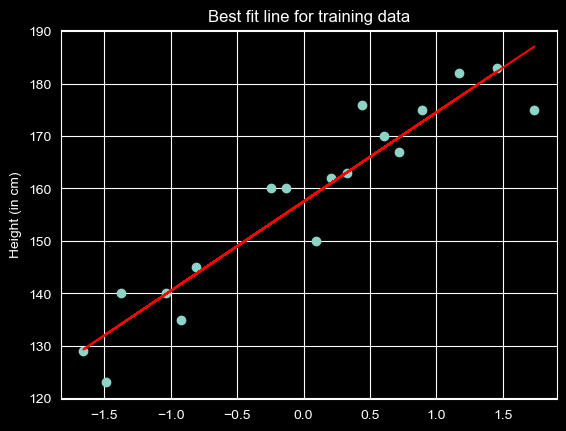

In [60]:
plt.scatter(X_train,y_train)
plt.plot(X_train,model.predict(X_train),'r')
plt.ylabel("Height (in cm)")
plt.title("Best fit line for training data")
plt.show()

## Prediction of train data

1. predicted height output = intercept + coef_(Weights)
2. y_pred_train = 157.5 + 17.03(X_train)

## Prediction of test data
1. predicted height output = intercept + coef_(Weights)
2. y_pred_test = 157.5 + 17.03(X_test)

In [55]:
y_pred_test = model.predict(X_test)

In [58]:
y_pred_test, y_test

(array([161.08467086, 161.08467086, 129.3041561 , 177.45645118,
        148.56507414]),
 15    177
 9     170
 0     120
 8     182
 17    159
 Name: Height, dtype: int64)

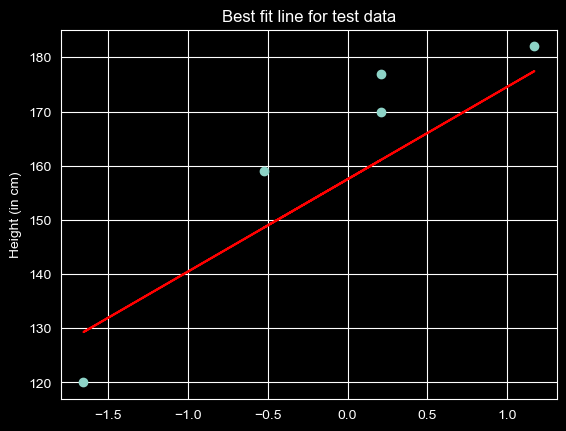

In [61]:
plt.scatter(X_test,y_test)
plt.plot(X_test,model.predict(X_test),'r')
plt.ylabel("Height (in cm)")
plt.title("Best fit line for test data")
plt.show()

In [65]:
## Performance Metrics
from sklearn.metrics import *

mse = mean_squared_error(y_test,y_pred_test)
mae = mean_absolute_error(y_test, y_pred_test)
rmse = np.sqrt(mse)
print("MSE:", np.round(mse,2))
print("MAE:", np.round(mae,2))
print("RMSE:", np.round(rmse,2))

MSE: 109.78
MAE: 9.82
RMSE: 10.48


## R Square
Formula

**R^2 = 1 - SSR/SST**

* R^2 = coefficient of determination
* SSR = Sum of squares of residuals
* SST = Total sum of squares

In [66]:
score = r2_score(y_test,y_pred_test)
print("R2 Score:",score)

R2 Score: 0.776986986042344


## Adjusted R Square
Formula

**Adjusted R2 = 1 - [(1-R2)*(n-1)/(n-k-1)]**

where:
* R2 = The R2 of the model
* n = The number of observations
* k: The number of predictor variables

In [67]:
# Displaying adjusted R Square value

print(1 - (1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1))

0.7026493147231252


In [68]:
model

LinearRegression()

In [78]:
## Suppose, new data point weight is 80
scaled_weight = scaler.transform([[80]])
scaled_weight[0]

D:\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([0.32350772])

In [79]:
print("The height prediction for weight 80 kg is:",model.predict([scaled_weight[0]]))

The height prediction for weight 80 kg is: [163.01076266]


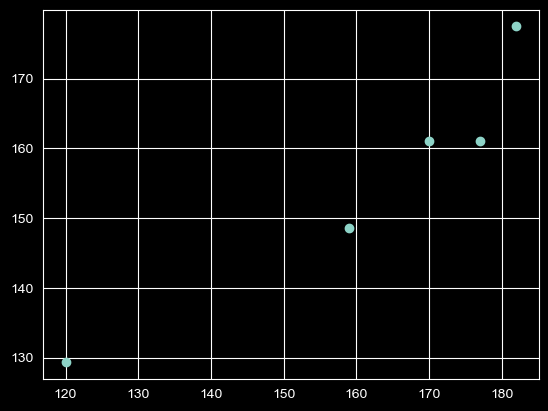

In [81]:
## Assumptions

## Plot a scatter plot for the prediction
plt.scatter(y_test,y_pred_test)
plt.show()

In [82]:
## Residuals
residuals = y_test - y_pred_test
residuals

15    15.915329
9      8.915329
0     -9.304156
8      4.543549
17    10.434926
Name: Height, dtype: float64

D:\Temp\UserTemp\ipykernel_13504\2140773374.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(residuals, kde=True)


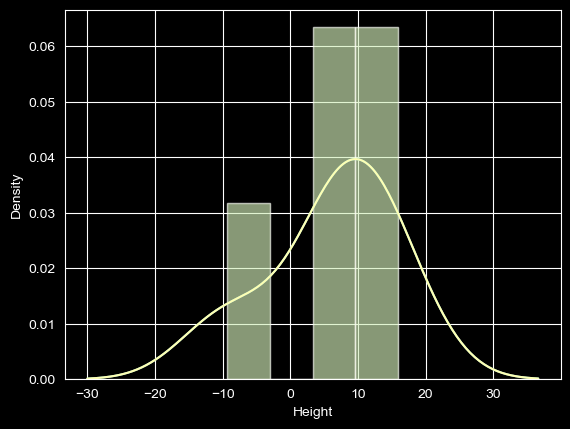

In [85]:
## Plotting the residuals
import seaborn as sns
sns.distplot(residuals, kde=True)
plt.show()

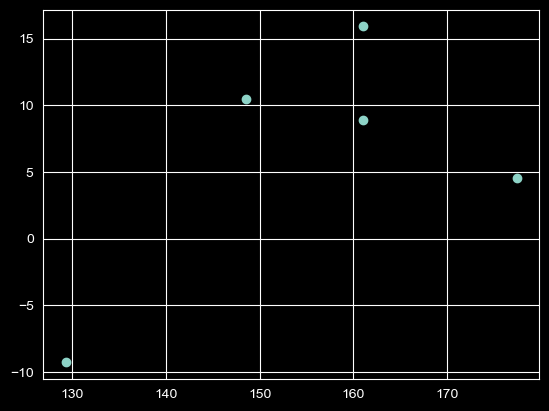

In [86]:
## Scatter plot w.r.t prediction and residuals
## Uniform distribution
plt.scatter(y_pred_test,residuals)
plt.show()